# Unsupervised Learning

In this field, we work with unlabeled data. While in supervised learning we try to generalize the data based on given target data, in unsupervised learning we create our own labels.

## Clustering

Cluster - group of nearly placed instances

### K-means

This algorithm works by defining centroids of clusters.


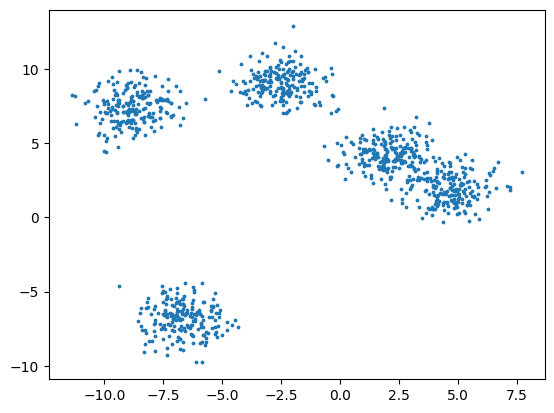

In [178]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=5, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

In [179]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
kmeans.labels_[:10]

array([4, 4, 0, 4, 1, 0, 3, 1, 4, 1], dtype=int32)

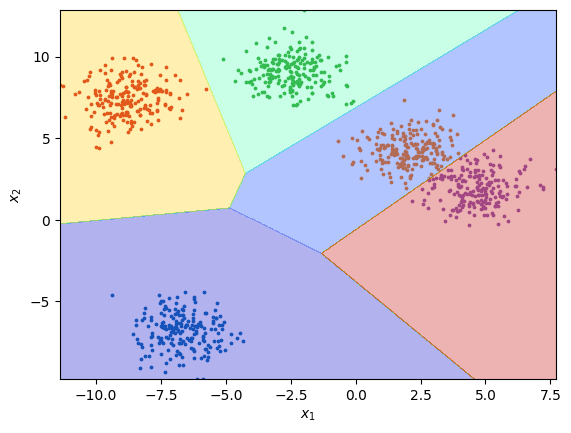

In [180]:
import numpy as np

def plot_2d_scatter_and_centers(X: np.typing.NDArray, kmeans: KMeans, resolution: int = 1000,  centers: np.typing.NDArray | None = None) -> None:
    for i in range(k):
        plt.scatter(X[:, 0][y_pred == i], X[:, 1][y_pred == i], s=3)

    X_mins = X.min(axis=0)
    X_maxs = X.max(axis=0)


    xx, yy = np.meshgrid(
        np.linspace(X_mins[0], X_maxs[0], resolution),
        np.linspace(X_mins[1], X_maxs[1], resolution)
    )

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, alpha=0.3, extent=(X_mins[0], X_maxs[0], X_mins[1], X_maxs[1]), cmap="jet")

    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="*", s=100, c="black")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")

    plt.show()

plot_2d_scatter_and_centers(X, kmeans)

In [181]:
kmeans.cluster_centers_

array([[-6.68630691, -6.81139455],
       [ 2.03639615,  4.26762858],
       [-2.50265159,  9.03963769],
       [-8.80798056,  7.40425704],
       [ 4.66534309,  1.87476184]])

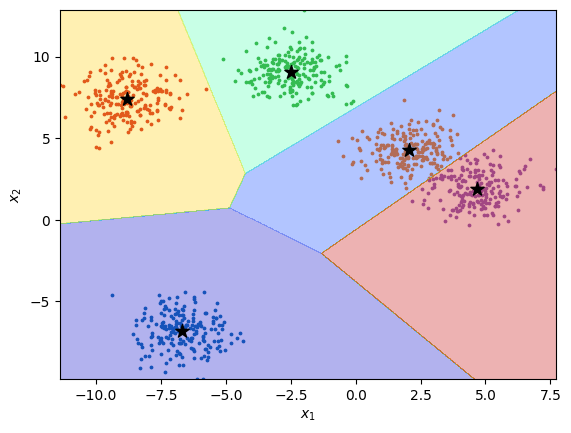

In [182]:
plot_2d_scatter_and_centers(X, kmeans, 1000, kmeans.cluster_centers_)

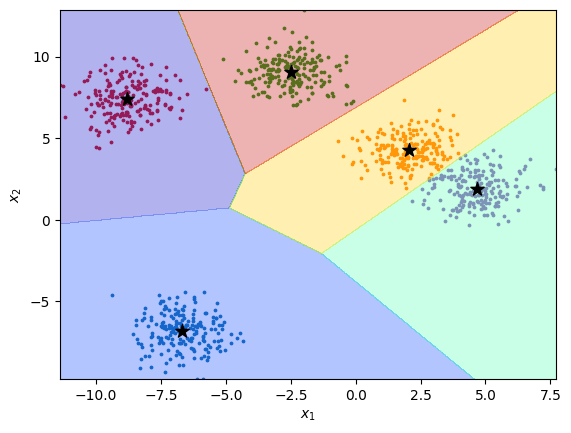

In [183]:
good_inits = np.array([
    [-8.5, 7],
    [-7.5, -6],
    [5, 0.5],
    [2.3, 4],
    [-2.3, 8.5]

])

kmeans = KMeans(n_clusters=5, init=good_inits, n_init=1)
kmeans.fit(X)
plot_2d_scatter_and_centers(X, kmeans, centers=kmeans.cluster_centers_)

In [184]:
kmeans.inertia_

1873.4290193066272

## Mini-Batch K-means

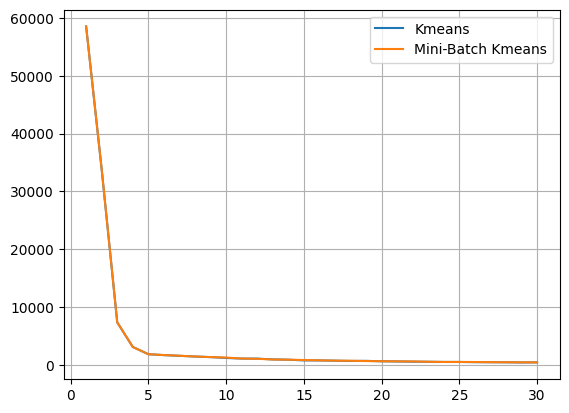

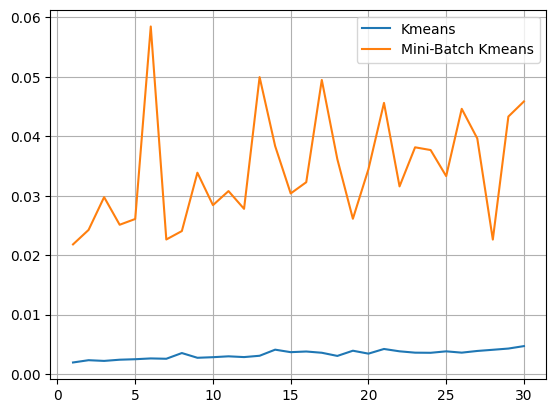

In [185]:
from sklearn.cluster import MiniBatchKMeans
import time

def plot_ks_inertia(k: int, X: np.typing.NDArray, skip_starting_k: int = 0) -> None:
    if skip_starting_k < 0:
        raise ValueError("You can't skip negative amount of instances")
    

    kmeans_plot_inertia = []
    kmeans_batch_plot_inertia = []

    for k_ in range(skip_starting_k+1, k+1):
        kmeans_batch = MiniBatchKMeans(n_clusters=k_).fit(X)
        kmeans = KMeans(n_clusters=k_).fit(X)

        kmeans_plot_inertia.append(kmeans.inertia_)
        kmeans_batch_plot_inertia.append(kmeans_batch.inertia_)
    
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_plot_inertia, label="Kmeans")
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_batch_plot_inertia, label="Mini-Batch Kmeans")

    plt.legend()
    plt.grid(True)
    plt.show()

def plot_ks_training_time(k: int, X: np.typing.NDArray, skip_starting_k: int = 0) -> None:
    if skip_starting_k < 0:
        raise ValueError("You can't skip negative amount of instances")
    
    kmeans_time = []
    kmeans_batch_time = []

    for k_ in range(skip_starting_k+1, k+1):
        start = time.perf_counter()
        MiniBatchKMeans(n_clusters=k_, n_init=1).fit(X)
        end = time.perf_counter()
        
        kmeans_batch_time.append(end - start)

        start = time.perf_counter()
        KMeans(n_clusters=k_, n_init=1).fit(X)
        end = time.perf_counter()

        kmeans_time.append(end - start)

    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_time, label="Kmeans")
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_batch_time, label="Mini-Batch Kmeans")

    plt.legend()
    plt.grid(True)
    plt.show()

plot_ks_inertia(k=30, X=X, skip_starting_k=0)
plot_ks_training_time(k=30, X=X, skip_starting_k=0)

## Clustering for Image Segmentation

Using clustering, we can assign each pixel to it's cluster using k-means to reduce number of colors in image.

In [186]:
import PIL

image = np.asarray(PIL.Image.open("pictures/serenity.png"))
image.shape

(600, 800, 3)

Dimensions are height, width and RGB color chanels.

Matplotlib could handle it, let's draw the image

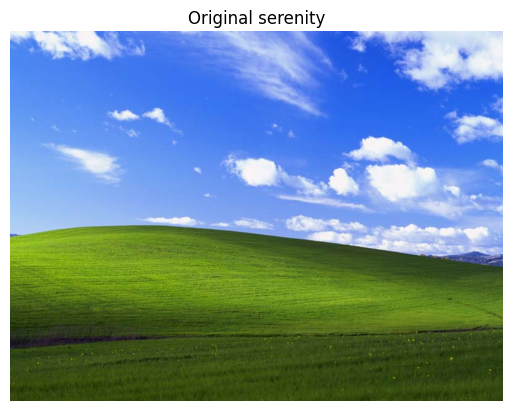

In [187]:
plt.imshow(image.astype(int))
plt.axis("off")
plt.title("Original serenity")
plt.show()

Now we need to get every pixel and it's color chanells as a matrix

In [188]:
X = image.reshape(-1, 3)
X.shape

(480000, 3)

And now, we can apply Kmeans, and replace each pixel with center of it's following centroid.

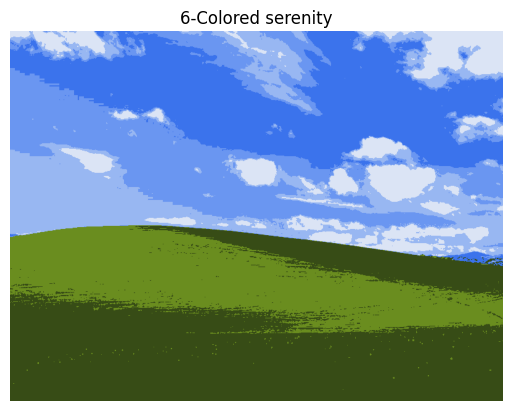

In [189]:
n_colors = 6

kmeans = KMeans(n_clusters=n_colors).fit(X)
segmented_image = kmeans.cluster_centers_[kmeans.labels_]
segmented_image = segmented_image.reshape(image.shape)

plt.imshow(segmented_image.astype(int))
plt.axis("off")
plt.title(f"{n_colors}-Colored serenity")
plt.show()

## Clustering for Semi-Supervised Learning (Label-Propagation)



We can use clustering for lable propagarion. In case when we don't have sufficient number of labels per instance in the dataset.

Let's load MNIST-like dataset for an example.

In [210]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)

X_digits_train, y_digits_train = X_digits[:1400], y_digits[:1400]
X_digits_test, y_digits_test = X_digits[1400:], y_digits[1400:]

Let't pretend that we have only 50 labeled instances, and train **Logistic Regression**

In [211]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(penalty="l2", max_iter=10_000, random_state=42)
lg = lg.fit(X_digits_train[:50], y_digits_train[:50])

In [212]:
lg.score(X_digits_test, y_digits_test)

0.7581863979848866

As you can see, accuracy is terrible. If we trained the model on the full dataset, we would achieve $90\%$ score.

We can try two ways to improve the model's performance.
We can cluster the dataset into $50$ clusters, then, for each cluster, we'll find image that is closest to the centroid. This is called - representative images.

In [213]:
k = 50
kmeans = KMeans(k, random_state=42)
X_digits_distance_space = kmeans.fit_transform(X_digits_train)
representative_digits_idx = np.argmin(X_digits_distance_space, axis=0)
X_representative_digits = X_digits_train[representative_digits_idx]

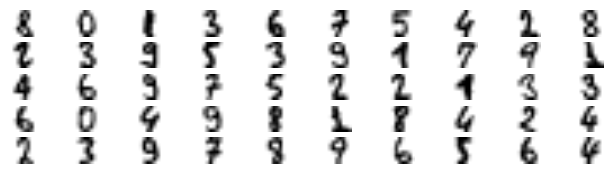

In [214]:
plt.figure(figsize=(8, 2))
for index, representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

Now we have digits that represent our dataset better than random chosen labels. 
Let's manually label them and and see whether our 50-label classifier performance would improve

In [215]:
y_representative_digits = np.array([
    8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
    2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
    4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
    6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
    2, 3, 9, 7, 8, 9, 6, 5, 6, 4
]) # manually labeled
lg = LogisticRegression(penalty="l2", random_state=42, max_iter=1_000)
lg.fit(X_representative_digits, y_representative_digits)
lg.score(X_digits_test, y_digits_test)

0.8337531486146096

Much better than was before!

We can take a one step further. And **propagate** those labels to all other instance of the training set in its corresponding cluster.

In [216]:
y_train_propagated = np.empty(len(X_digits_train), dtype=np.int64)
for i in range(len(y_representative_digits)):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

Let's see the results...

In [217]:
lg = LogisticRegression(penalty="l2", random_state=42, max_iter=1_000)
lg.fit(X_digits_train, y_train_propagated)
lg.score(X_digits_test, y_digits_test)

0.8690176322418136

A little better! 
We can try to improve the results even more. Like ignoring instances that are farthest from theirs cluster.

In [218]:
percentile_closest = 99

X_cluster_dist = X_digits_distance_space[np.arange(len(X_digits_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_digits_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [220]:
print(f"Lost {len(X_digits_train) - len(X_train_partially_propagated)} entries")

lg = LogisticRegression(penalty="l2", random_state=42, max_iter=1_000)
lg.fit(X_train_partially_propagated, y_train_partially_propagated)
print(f"Accuracy - {np.round(lg.score(X_digits_test, y_digits_test), 2)}")

print(f"Propagated labels accuracy: {(y_train_partially_propagated == y_digits_train[y_train_partially_propagated])}")

Lost 50 entries
Accuracy - 0.86
Propagated labels accuracy: [ True  True  True ...  True  True  True]


We didn't get better results, as was expected. But, you got the idea. Maybe the issue is bad manual labeling.